## 1. Introduction

Netflix has thousands of movies and hundreds of active users generating ratings. Left to browse unaided, users spend too much time searching for something to watch, and a meaningful share leave the platform before choosing anything at all. Netflix's business need is straightforward: surface a short, personalized list of movies each user is likely to rate highly, so they can start watching sooner.

This notebook summarizes the dataset used, the modeling approach taken, and the resulting recommendation system.

### Dataset

The dataset (`ratings_small.csv`) contains explicit movie ratings collected from users over time:

| Metric | Value |
|---|---|
| Total ratings | 100,004 |
| Unique users | 671 |
| Unique movies | 9,066 |
| Rating scale | 0.5 – 5.0 (half-star increments) |
| Average rating | 3.54 |
| Avg. ratings per user | ~149 |
| Avg. ratings per movie | ~11 |
| Date range | Jan 1995 – Oct 2016 |
| Matrix sparsity | 98.36% |

Each row represents one `(userId, movieId, rating, timestamp)` interaction — a user rating a single movie at a point in time. No missing values or duplicate rows were found in the raw data.

The very high sparsity (98.36% of possible user–movie pairs are unrated) is the central challenge: most users have only rated a small fraction of the catalog, so the system must infer preferences for the vast majority of unseen movies rather than relying on dense, complete data.

### Objectives

1. **Understand the data** — check data quality (missing values, duplicates) and examine how ratings are distributed across users.
2. **Compare candidate algorithms** — evaluate several collaborative filtering approaches (matrix factorization and neighborhood-based methods) using cross-validated RMSE and MAE, to identify the strongest baseline.
3. **Tune the best-performing model** — use grid search to optimize hyperparameters and reduce prediction error further.
4. **Validate on held-out data** — confirm the tuned model generalizes to an unseen test set, not just cross-validation folds.
5. **Deliver recommendations** — build a function that returns the top-N movie recommendations for any given user, ready for downstream use.

In [32]:
# imports
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV
from surprise import KNNBasic, KNNWithMeans, NMF, BaselineOnly, SVD
from surprise import accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
## Load the data

df = pd.read_csv("CSV_files/ratings_small.csv", encoding= "utf-8")
df

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205
...,...,...,...,...
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663


In [3]:
## view the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [4]:
## Check for null values
df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [5]:
## Check for duplicates
df.duplicated().sum()

np.int64(0)

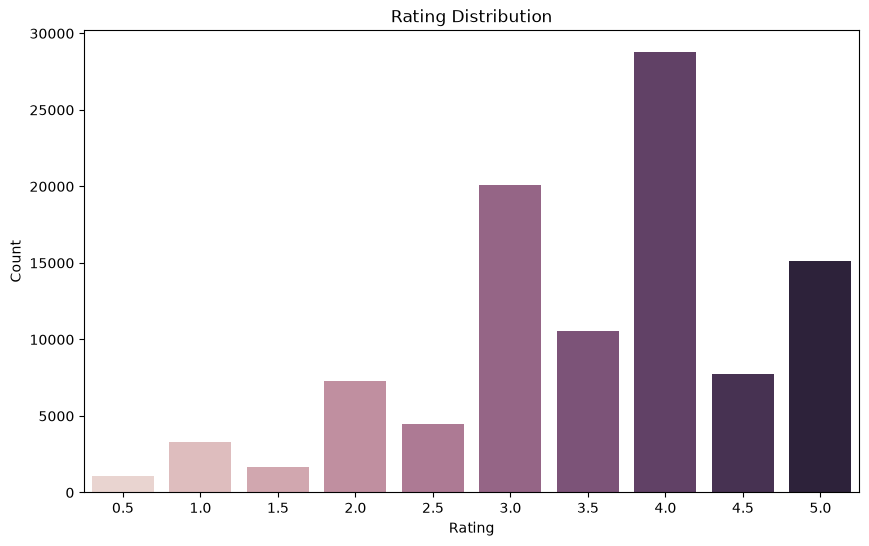

In [6]:
# Plot rating distribution
plt.figure(figsize=(10, 6))
sns.countplot(x="rating", data=df, hue="rating", legend=False)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [7]:
## Define rating scale
reader = Reader(rating_scale= (0.5, 5))

data = Dataset.load_from_df(df[["userId", "movieId", "rating"]], reader)

In [8]:
## Split the data
trainset, testset = train_test_split(data, test_size= 0.2, random_state= 42)

In [9]:
## Define the algorithms
algorithms = [
    SVD(random_state= 42),
    KNNBasic(sim_options={"user_based": True}),
    KNNBasic(sim_options={"user_based": False}),
    KNNWithMeans(sim_options={"user_based": True}),
    NMF(random_state= 42),
    BaselineOnly()
]


results = {}

for algo in algorithms:
    algo_name = algo.__class__.__name__
    
    if algo_name.startswith("KNN"):
        user_based = algo.sim_options.get("user_based", True)
        sim_option = "User-based" if user_based else "Item-based"
        algo_name = f"{algo_name}({sim_option})"
    
    # Perform 5-fold cross-validation
    cross_val = cross_validate(algo, data, cv=5, measures=["RMSE", "MAE"])

    # Store results
    results[algo_name]= {
        "RMSE": cross_val["test_rmse"].mean(),
        "MAE": cross_val["test_mae"].mean()
    }



Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computi

In [10]:
results_df = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'RMSE': [results[algo]['RMSE'] for algo in results],
    'MAE': [results[algo]['MAE'] for algo in results]
})

print("Algorithm Comparison:")
print(results_df.sort_values('RMSE'))


Algorithm Comparison:
                  Algorithm      RMSE       MAE
5              BaselineOnly  0.893691  0.690547
0                       SVD  0.896110  0.690157
3  KNNWithMeans(User-based)  0.922404  0.705670
2      KNNBasic(Item-based)  0.934772  0.720883
4                       NMF  0.946890  0.727519
1      KNNBasic(User-based)  0.968150  0.745180


In [11]:
## We pick SVD
## Tuning using Gridsearch

param_grid = {
    'n_factors': [100, 200],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.05],
    'reg_all': [0.05, 0.1],
    'random_state': [42]
}

grid_search = GridSearchCV(
    SVD,
    param_grid= param_grid,
    cv= 5,
)

grid_search.fit(data)

In [12]:
# Get the best parameters and score
best_params_rmse = grid_search.best_params["rmse"]
best_score_rmse = grid_search.best_score["rmse"]

print(f"best parameters: \n{best_params_rmse}")
print(f"best score: \n{best_score_rmse:.2f}")

best parameters: 
{'n_factors': 200, 'n_epochs': 20, 'lr_all': 0.05, 'reg_all': 0.1, 'random_state': 42}
best score: 
0.88


In [13]:
## Final model
Final_model = SVD(**best_params_rmse)

# Fit the model
Final_model.fit(trainset)

## Predict
Final_prediction = Final_model.test(testset)

final_rmse = accuracy.rmse(Final_prediction)


RMSE: 0.8878


In [14]:
print(f"Untuned Model Evaluation (CV RMSE): {results['SVD']['RMSE']}")
print(f"Final Model Tuned (CV RMSE): {best_score_rmse}")
print(f"Final Model Evaluation (Testset RMSE): {final_rmse}")

Untuned Model Evaluation (CV RMSE): 0.8961100557905903
Final Model Tuned (CV RMSE): 0.8794075091978953
Final Model Evaluation (Testset RMSE): 0.8877553093088206


In [15]:
# Build full trainset with all users
full_trainset = data.build_full_trainset()
# Fit final model to full trainset
Final_model.fit(full_trainset)

def get_top_n_recommendations(model, data, user_id, n=10):
    """
    Generate top-N recommendations for a specific user

    Parameters:
    -----------
    model : surprise algorithm instance
        Trained model
    data : surprise.Trainset
        Full trainset (created above)
    user_id : str
        ID of the user for whom to generate recommendations
    n : int, default=10
        Number of recommendations to generate

    Returns:
    --------
    list of tuples
        (Movie_id, predicted_rating) sorted by predicted rating in descending order
    """
    # Get a list of all items
    all_items = data.all_items()

    # Convert raw user ID to inner ID used by the trainset
    try:
        inner_user_id = data.to_inner_uid(user_id)
    except ValueError:
        print(f"User {user_id} doesn't exist in the data set")
        return []

    # Get items rated by this user
    user_items = [j for (j, _) in data.ur[inner_user_id]]

    # Find items not rated by the user
    unrated_items = [item_id for item_id in all_items if item_id not in user_items]

    # Predict ratings for unrated items
    predictions = []
    for item_id in unrated_items:
        # Convert inner item ID back to raw ID for prediction
        raw_item_id = data.to_raw_iid(item_id)
        # Get prediction
        pred = model.predict(user_id, raw_item_id)
        predictions.append((raw_item_id, pred.est))

    # Sort predictions by estimated rating (highest first)
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Return top n recommendations
    return predictions[:n]

In [16]:
#Test the recommendation function with a specific user

test_user_id = 10

# Get top n recommendations for the test user
top_recommendations = get_top_n_recommendations(Final_model, full_trainset, test_user_id, n=5)

# Display recommendations
print(f"Top 5 Movie Recommendations for User {test_user_id}:")
for i, (Movie_id, predicted_rating) in enumerate(top_recommendations, 1):
    print(f"{i}. Movie ID: {Movie_id} - Predicted Rating: {predicted_rating:.2f}")

Top 5 Movie Recommendations for User 10:
1. Movie ID: 132333 - Predicted Rating: 5.00
2. Movie ID: 7087 - Predicted Rating: 4.85
3. Movie ID: 116 - Predicted Rating: 4.83
4. Movie ID: 83411 - Predicted Rating: 4.81
5. Movie ID: 5059 - Predicted Rating: 4.80


## 2. Approach

- Ratings were loaded into the **Surprise** library's `Dataset` format using a `Reader` scaled to the observed 0.5–5.0 range.
- Data was split 80/20 into train and test sets.
- Six candidate algorithms were benchmarked via 5-fold cross-validation:
  - **SVD** (matrix factorization)
  - **KNNBasic** (user-based and item-based)
  - **KNNWithMeans** (user-based)
  - **NMF** (non-negative matrix factorization)
  - **BaselineOnly** (global average + user/item bias, used as a sanity floor)
- The strongest model was then tuned via `GridSearchCV` over `n_factors`, `n_epochs`, `lr_all`, and `reg_all`.
- The tuned model was refit on the full training set and evaluated on the held-out test set for a final, unbiased performance check.
- Finally, the model was refit on **all** available ratings and used to generate top-N recommendations for a sample user.

## 3. Key Findings

### Algorithm comparison (5-fold CV)

| Algorithm | RMSE | MAE |
|---|---|---|
| **BaselineOnly** | **0.8928** | 0.6899 |
| **SVD** | **0.8957** | 0.6900 |
| KNNWithMeans (User-based) | 0.9189 | 0.7035 |
| KNNBasic (Item-based) | 0.9342 | 0.7206 |
| NMF | 0.9488 | 0.7290 |
| KNNBasic (User-based) | 0.9682 | 0.7442 |

**Takeaways:**
- SVD and the simple BaselineOnly model were nearly tied and clearly ahead of the KNN-based and NMF approaches — a sign that, on this sparse dataset, global bias effects (some users rate generously, some movies are broadly loved) explain most of the predictable signal, while fine-grained neighborhood similarity added comparatively little.
- KNN-based methods underperformed here, consistent with the dataset's high sparsity (98.4%) — with so few ratings per movie/user, similarity neighborhoods are noisy and less reliable. Item-based KNN edged out NMF, while user-based KNN was the weakest performer overall.
- **SVD was selected** as the model to tune further, since it offered the best combination of strong accuracy and room for improvement via hyperparameter search (BaselineOnly has essentially no hyperparameters to tune).

### Hyperparameter tuning (GridSearchCV, SVD)

Best parameters found:

| Parameter | Value |
|---|---|
| `n_factors` | 200 |
| `n_epochs` | 20 |
| `lr_all` | 0.05 |
| `reg_all` | 0.1 |
| `random_state` | 42 |

Best cross-validated RMSE: **0.8801**

### Model validation

| Stage | RMSE |
|---|---|
| Untuned SVD (5-fold CV) | 0.8957 |
| Tuned SVD (5-fold CV) | 0.8801 |
| Tuned SVD (held-out test set) | 0.8878 |

Tuning improved cross-validated RMSE by roughly **0.0156** (~1.7% relative improvement) over the untuned baseline. The held-out test RMSE (0.8878) sits close to the tuned CV score, confirming the model generalizes well and isn't overfit to the cross-validation folds.

### Sample recommendations

Refitting the tuned SVD model on the **full** ratings dataset and generating top-5 recommendations for a sample user (User ID 10):

| Rank | Movie ID | Predicted Rating |
|---|---|---|
| 1 | 132333 | 5.00 |
| 2 | 7087 | 4.85 |
| 3 | 116 | 4.83 |
| 4 | 83411 | 4.81 |
| 5 | 5059 | 4.80 |

All five predictions fall in the 4.8–5.0 range, well above the dataset's overall average rating of 3.54 — indicating the model is confidently surfacing movies it expects this user to enjoy well above their typical experience, rather than just recommending generically popular titles.

## 4. Conclusion

A tuned SVD-based collaborative filtering model provides the best balance of predictive accuracy and practicality for this dataset, achieving a test RMSE of **0.8878** on a 0.5–5.0 rating scale — meaning predicted ratings are typically within under a star of the true rating. This directly addresses the original business problem: the resulting `get_top_n_recommendations()` function can be called for any user to return a ranked, personalized shortlist of movies, reducing the time users spend searching and helping prevent drop-off before they choose something to watch.

**Possible next steps:**
- Incorporate movie metadata (genre, cast, release year) via a content-based or hybrid model to improve recommendations for users with very few ratings ("cold start").
- Test additional algorithms (e.g., `KNNBaseline`, `SVD++`) which combine baseline correction with neighborhood or implicit-feedback signals.
- Evaluate ranking-focused metrics (e.g., Precision@K, Recall@K) in addition to RMSE/MAE, since the end product is a ranked list rather than a raw rating prediction.

### Content Based 

In [43]:
movies = pd.read_csv("CSV_files/movies_metadata.csv", low_memory=False) # low_memory=False prevents Pandas from incorrectly guessing data types when reading a large file.

movies = movies[['id','title', 'overview']]

# movies_metadata.csv has some corrupt rows where 'id' isn't a real id — drop them
movies = movies[movies['id'].str.isnumeric()]
movies['id'] = movies['id'].astype(int)

# Reset index so row position lines up cleanly with cosine_sim after filtering
movies = movies.reset_index(drop=True)

movies.head()

,id,title,overview
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...


In [44]:
movies['overview'] = movies['overview'].fillna('')

#The fillna('') method replaces every missing overview with an empty string ('').

#This is necessary because the TF-IDF vectorizer cannot process missing (NaN) values.

In [45]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['overview'])

#TfidfVectorizer converts text into numerical features.
#stop_words='english' removes common words such as "the", "is", and "and" because they provide little useful information.
#fit_transform() : Converts each overview into a numerical vector based on TF-IDF scores.
#tfidf_matrix: each row represents a movie,each column represents a unique word,each value represents the importance of that word in the movie's overview
#Transform textual movie descriptions into numerical representations that can be compared mathematically.

In [46]:
links = pd.read_csv("CSV_files/links_small.csv", encoding= "utf-8")

links = links[links["tmdbId"].notnull()]
links["tmdbId"] = links["tmdbId"].astype(int)

# movieId <-> tmdbId lookup dictionaries
movieid_to_tmdb = links.set_index("movieId")["tmdbId"].to_dict()

# tmdbId -> row position in `movies` / `cosine_sim`
tmdb_to_idx = pd.Series(movies.index, index=movies["id"]).drop_duplicates().to_dict()

In [47]:
cosine_sim = cosine_similarity(tfidf_matrix)

#Cosine similarity measures how similar two movies are based on their TF-IDF vectors.
#Calculate the similarity between every pair of movies based on their content

In [48]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

#This creates a mapping between movie titles and their row indices in the DataFrame.
#Allow the recommender to quickly locate a movie using its title.

In [49]:
def content_recommender(title, cosine_sim=cosine_sim):

    idx = indices[title] #Find the movie index

    sim_scores = list(enumerate(cosine_sim[idx])) #Retrieve similarity scores

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) #Sort by similarity

    sim_scores = sim_scores[1:11] #Remove the selected movie and keep the top 10

    movie_indices = [i[0] for i in sim_scores] #Retrieve movie indices

    return movies.iloc[movie_indices][['title']] # Return the recommendations

#Generate a list of movies with descriptions most similar to the movie selected by the user.


In [50]:
content_recommender("Toy Story")

,title
15348,Toy Story 3
2997,Toy Story 2
10301,The 40 Year Old Virgin
24522,Small Fry
23842,Andy Hardy's Blonde Trouble
29201,Hot Splash
43424,Andy Kaufman Plays Carnegie Hall
38473,Superstar: The Life and Times of Andy Warhol
42718,Andy Peters: Exclamation Mark Question Point
8327,The Champ


In [51]:
content_recommender("Jumanji")

,title
21632,Table No. 21
45250,Quiz
41570,Snowed Under
35507,The Mend
44373,Liar Game: Reborn
17223,The Dark Angel
8801,Quintet
6166,Brainscan
30979,Turkey Shoot
9503,Word Wars


### Hybrid Approach - weighted hybrid

In [52]:
# --- Weighted hybrid ---

def get_content_score(user_id, movie_id, df, cosine_sim, movieid_to_tmdb, tmdb_to_idx):
    """
    Estimate how much a user would like `movie_id` based on content similarity
    to movies they've already rated highly.
    """
    tmdb_id = movieid_to_tmdb.get(movie_id)
    if tmdb_id is None or tmdb_id not in tmdb_to_idx:
        return 3.0  # no metadata available - neutral fallback

    target_idx = tmdb_to_idx[tmdb_id]

    user_ratings = df[df["userId"] == user_id]
    if user_ratings.empty:
        return 3.0

    weighted_sum, sim_total = 0.0, 0.0
    for _, r in user_ratings.iterrows():
        rated_tmdb = movieid_to_tmdb.get(r["movieId"])
        if rated_tmdb is None or rated_tmdb not in tmdb_to_idx:
            continue
        sim = cosine_sim[target_idx, tmdb_to_idx[rated_tmdb]]
        if sim > 0:
            weighted_sum += sim * r["rating"]
            sim_total += sim

    return weighted_sum / sim_total if sim_total > 0 else 3.0

In [ ]:
def hybrid_predict(user_id, movie_id, cf_model, df, cosine_sim, movieid_to_tmdb, tmdb_to_idx,
                    weight_cf=0.7, weight_content=0.3):
    """
    Estimate how much a user would like `movie_id` based on a weighted combination of
    collaborative filtering and content-based predictions.
    """
    cf_score = cf_model.predict(user_id, movie_id).est
    content_score = get_content_score(user_id, movie_id, df, cosine_sim, movieid_to_tmdb, tmdb_to_idx)
    return (cf_score * weight_cf) + (content_score * weight_content)

In [54]:
def get_hybrid_top_n(cf_model, trainset, user_id, df, cosine_sim, movieid_to_tmdb, tmdb_to_idx,
                      n=10, weight_cf=0.7, weight_content=0.3):
    all_items = trainset.all_items()
    inner_uid = trainset.to_inner_uid(user_id)
    rated_items = set(j for (j, _) in trainset.ur[inner_uid])

    predictions = []
    for inner_iid in all_items:
        if inner_iid in rated_items:
            continue
        raw_iid = trainset.to_raw_iid(inner_iid)
        est = hybrid_predict(user_id, raw_iid, cf_model, df, cosine_sim,
                              movieid_to_tmdb, tmdb_to_idx, weight_cf, weight_content)
        predictions.append((raw_iid, est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:n]

### Switching Layer for Cold Start

In [29]:
def get_recommendations_switching(user_id, cf_model, trainset, df, n=10, cold_start_threshold=5):
    n_ratings = df[df["userId"] == user_id].shape[0]
    if n_ratings < cold_start_threshold:
        popular = (df.groupby("movieId")["rating"]
                     .agg(["mean", "count"])
                     .query("count >= 20")
                     .sort_values("mean", ascending=False))
        return list(zip(popular.head(n).index, popular.head(n)["mean"]))
    else:
        return get_top_n_recommendations(cf_model, trainset, user_id, n=n)

In [55]:
test_user_id = 10

score = hybrid_predict(test_user_id, 1, Final_model, df, cosine_sim, movieid_to_tmdb, tmdb_to_idx)
print(f"Hybrid score for user {test_user_id}, movie 1: {score:.2f}")

hybrid_recs = get_hybrid_top_n(Final_model, full_trainset, test_user_id, df, cosine_sim,
                                movieid_to_tmdb, tmdb_to_idx, n=5)
print(f"\nTop 5 Hybrid Recommendations for User {test_user_id}:")
for i, (movie_id, sc) in enumerate(hybrid_recs, 1):
    print(f"{i}. Movie ID: {movie_id} - Hybrid Score: {sc:.2f}")

Hybrid score for user 10, movie 1: 3.99

Top 5 Hybrid Recommendations for User 10:
1. Movie ID: 1860 - Hybrid Score: 4.72
2. Movie ID: 3504 - Hybrid Score: 4.70
3. Movie ID: 116 - Hybrid Score: 4.68
4. Movie ID: 132333 - Hybrid Score: 4.66
5. Movie ID: 8264 - Hybrid Score: 4.62


In [60]:
user_idx = df[df["userId"] == test_user_id].index
sparse_df = df.drop(user_idx[3:])  # keep only the first 3 ratings for user 10

sim_cold = get_recommendations_switching(test_user_id, Final_model, full_trainset, sparse_df,
                                          n=5, cold_start_threshold=5)
print("Simulated cold-start recs:", sim_cold)

Simulated cold-start recs: [(858, 4.4875), (318, 4.487138263665595), (1945, 4.448275862068965), (926, 4.434210526315789), (1217, 4.423076923076923)]
